# Two-Dimensional Advection on a Periodic Domain

Advection models pure transport: a scalar quantity moves with a velocity field without local production or destruction. It appears in fluid simulation, atmospheric transport, level-set methods, and texture dynamics.

The practical stakes are numerical: transport should remain stable, preserve geometric structures as much as possible, and avoid boundary artifacts. This notebook studies a semi-Lagrangian scheme on a torus-like periodic grid.

We solve
$$
\partial_t f + u\cdot\nabla f = 0,
$$
with a backward characteristic update
$$
f^{k+1}(x) = f^k\big(x-\rho u(x)\big).
$$

## Environment and symbols

The scalar field is stored as a matrix $f\in\mathbb{R}^{n\times n}$ and the velocity as $u\in\mathbb{R}^{n\times n\times 2}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider

plt.rcParams['figure.dpi'] = 120
rng = np.random.default_rng(1234)

## Periodic smoothing and interpolation operators

We build a smooth flow by filtering random noise with a periodic Gaussian kernel, then define a periodic bilinear warp operator.

In [2]:
def gaussian_kernel_2d(n, sigma):
    t = np.r_[np.arange(0, n // 2 + 1), np.arange(-n // 2 + 1, 0)]
    g1 = np.exp(-(t**2) / (2 * sigma**2))
    G = np.outer(g1, g1)
    return G / G.sum()

def periodic_gaussian_filter(f, sigma):
    n = f.shape[0]
    G = gaussian_kernel_2d(n, sigma)
    return np.fft.ifft2(np.fft.fft2(f) * np.fft.fft2(G)).real

def warp_periodic_bilinear(f, U):
    n = f.shape[0]
    yy, xx = np.meshgrid(np.arange(n), np.arange(n), indexing='ij')
    x = (xx - U[..., 0]) % n
    y = (yy - U[..., 1]) % n
    x0 = np.floor(x).astype(int)
    y0 = np.floor(y).astype(int)
    x1 = (x0 + 1) % n
    y1 = (y0 + 1) % n
    wx = x - x0
    wy = y - y0
    f00 = f[y0, x0]
    f10 = f[y0, x1]
    f01 = f[y1, x0]
    f11 = f[y1, x1]
    return (
        (1 - wx) * (1 - wy) * f00
        + wx * (1 - wy) * f10
        + (1 - wx) * wy * f01
        + wx * wy * f11
    )

## Initial condition

We use a high-contrast grid texture to make transport distortions visually explicit.

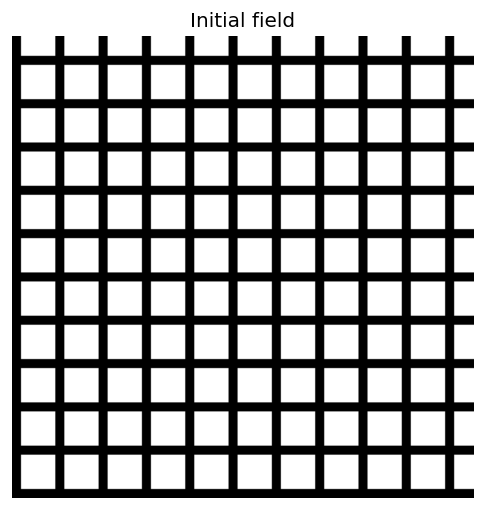

In [3]:
n = 256
Y, X = np.meshgrid(np.arange(n), np.arange(n), indexing='ij')
cell = 24
line = 4
f0 = 1.0 - ((X % cell <= line) | (Y % cell <= line)).astype(float)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(f0, cmap='gray', origin='lower')
ax.set_title('Initial field')
ax.axis('off')
plt.show()

## Smooth velocity field

We draw two Gaussian-smoothed random components and normalize to set a controlled transport speed.

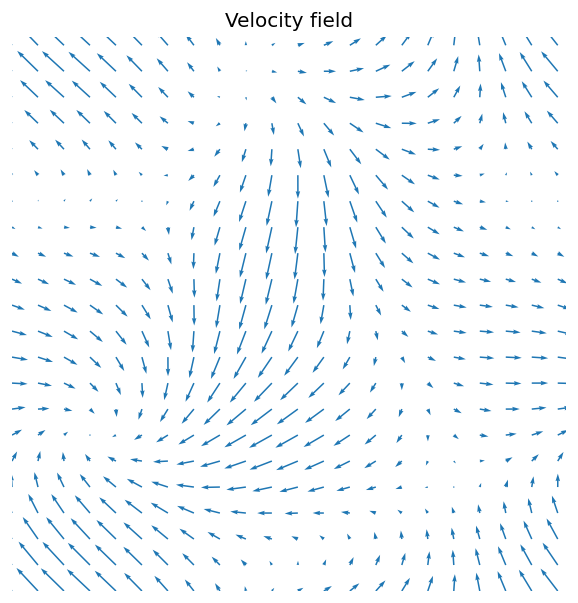

In [4]:
sigma_flow = 40
u1 = periodic_gaussian_filter(rng.standard_normal((n, n)), sigma_flow)
u2 = periodic_gaussian_filter(rng.standard_normal((n, n)), sigma_flow)
U = np.stack([u1, u2], axis=-1)
U /= np.max(np.abs(U)) + 1e-12

step = 12
fig, ax = plt.subplots(figsize=(6, 6))
ax.quiver(
    X[::step, ::step], Y[::step, ::step],
    U[::step, ::step, 0], U[::step, ::step, 1],
    color='tab:blue', angles='xy', scale_units='xy', scale=0.08,
)
ax.set_aspect('equal')
ax.set_xlim(0, n)
ax.set_ylim(0, n)
ax.axis('off')
ax.set_title('Velocity field')
plt.show()

## Semi-Lagrangian solver

Iterating
$$
f^{k+1}=\mathcal W_{\rho u}(f^k)
$$
produces an unconditionally stable transport scheme, at the cost of interpolation-induced numerical diffusion.

In [5]:
def advect(f_init, U, rho=3.0, n_steps=80):
    frames = [f_init.copy()]
    f = f_init.copy()
    for _ in range(n_steps):
        f = warp_periodic_bilinear(f, rho * U)
        frames.append(f.copy())
    return frames

frames = advect(f0, U, rho=3.0, n_steps=80)
print('Generated frames:', len(frames))

Generated frames: 81


## Interactive time evolution

The slider explores the time index $k$ in the transported sequence $(f^k)_k$.

In [ ]:
def show_frame(t=0):
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    ax.imshow(frames[t], cmap='gray', origin='lower', vmin=0, vmax=1)
    ax.set_title(f'Frame t={t}')
    ax.axis('off')
    plt.show()

interact(show_frame, t=IntSlider(min=0, max=len(frames)-1, step=1, value=0));

interactive(children=(IntSlider(value=0, description='t', max=80), Output()), _dom_classes=('widget-interact',…

## Sensitivity to transport amplitude

We vary $\rho$ in
$$
x\mapsto x-\rho u(x),
$$
to visualize how step size changes deformation strength and smoothing artifacts.

In [7]:
def preview_rho(rho=3.0, t=40):
    local_frames = advect(f0, U, rho=rho, n_steps=max(t, 1))
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
    axes[0].imshow(f0, cmap='gray', origin='lower', vmin=0, vmax=1)
    axes[0].set_title('Initial')
    axes[1].imshow(local_frames[t//2], cmap='gray', origin='lower', vmin=0, vmax=1)
    axes[1].set_title(f'Mid (t={t//2})')
    axes[2].imshow(local_frames[t], cmap='gray', origin='lower', vmin=0, vmax=1)
    axes[2].set_title(f'Final (t={t})')
    for ax in axes:
        ax.axis('off')
    plt.show()

interact(
    preview_rho,
    rho=FloatSlider(min=0.5, max=5.0, step=0.25, value=3.0),
    t=IntSlider(min=10, max=80, step=2, value=40),
);

interactive(children=(FloatSlider(value=3.0, description='rho', max=5.0, min=0.5, step=0.25), IntSlider(value=…

## Bibliographical resources

- Randall J. LeVeque, *Finite Volume Methods for Hyperbolic Problems*.
- Jos Stam, *Stable Fluids*, SIGGRAPH 1999.
- Dmitri P. Bertsekas, *Dynamic Programming and Optimal Control* (for characteristic viewpoints in transport/control settings).